<a href="https://colab.research.google.com/github/mariavasylets/1/blob/master/pr6Vasylets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt



In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/police_project.csv")
df.head()

,stop_date,stop_time,county_name,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,2005-01-02,01:55,NaN,M,1985.0,20.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
1,2005-01-18,08:15,NaN,M,1965.0,40.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
2,2005-01-23,23:15,NaN,M,1972.0,33.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
3,2005-02-20,17:15,NaN,M,1986.0,19.0,White,Call for Service,Other,False,NaN,Arrest Driver,True,16-30 Min,False
4,2005-03-14,10:00,NaN,F,1984.0,21.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False


In [6]:
df.shape

(91741, 15)

In [7]:
df.columns

Index(['stop_date', 'stop_time', 'county_name', 'driver_gender',
       'driver_age_raw', 'driver_age', 'driver_race', 'violation_raw',
       'violation', 'search_conducted', 'search_type', 'stop_outcome',
       'is_arrested', 'stop_duration', 'drugs_related_stop'],
      dtype='object')

In [8]:
df.dtypes

,0
stop_date,object
stop_time,object
county_name,float64
driver_gender,object
driver_age_raw,float64
driver_age,float64
driver_race,object
violation_raw,object
violation,object
search_conducted,bool


In [9]:
df.nunique()

,0
stop_date,3768
stop_time,1436
county_name,0
driver_gender,2
driver_age_raw,97
driver_age,78
driver_race,5
violation_raw,12
violation,6
search_conducted,2


In [10]:
df.isnull().sum()

,0
stop_date,0
stop_time,0
county_name,91741
driver_gender,5335
driver_age_raw,5327
driver_age,5621
driver_race,5333
violation_raw,5333
violation,5333
search_conducted,0


In [11]:
speeding = df[df['violation'] == 'Speeding']
print(speeding['driver_gender'].value_counts())

driver_gender
M    32979
F    15482
Name: count, dtype: int64


In [12]:
print(df.groupby('driver_gender')['search_conducted'].mean())

driver_gender
F    0.020033
M    0.043326
Name: search_conducted, dtype: float64


search_type
Incident to Arrest                                          1219
Probable Cause                                               891
Inventory                                                    220
Reasonable Suspicion                                         197
Protective Frisk                                             161
Incident to Arrest,Inventory                                 129
Incident to Arrest,Probable Cause                            106
Probable Cause,Reasonable Suspicion                           75
Incident to Arrest,Inventory,Probable Cause                   34
Incident to Arrest,Protective Frisk                           33
Probable Cause,Protective Frisk                               33
Inventory,Probable Cause                                      22
Incident to Arrest,Reasonable Suspicion                       13
Inventory,Protective Frisk                                    11
Protective Frisk,Reasonable Suspicion                         11
Incident to A

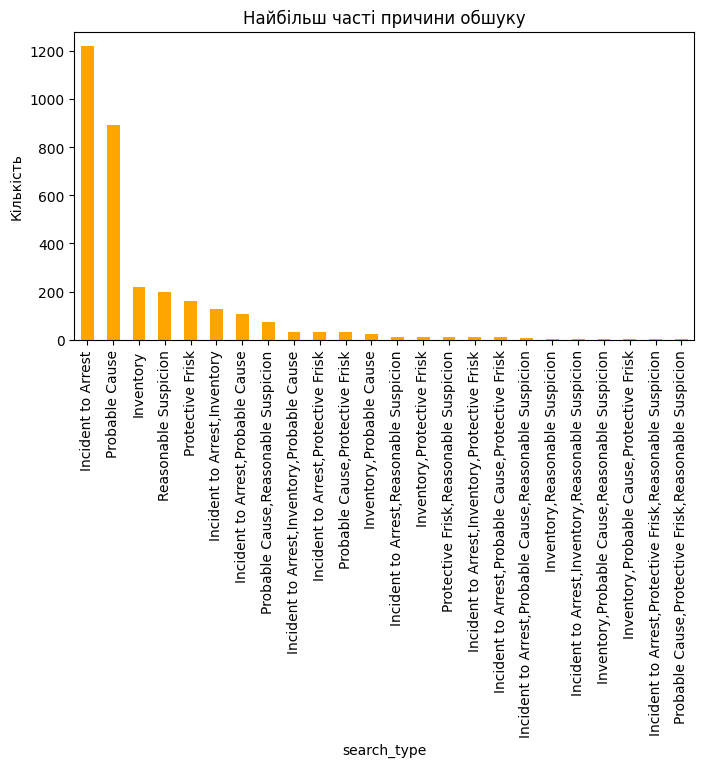

In [13]:
print(df['search_type'].value_counts())

df['search_type'].value_counts().plot(kind='bar', figsize=(8,4), color="orange")
plt.title("Найбільш часті причини обшуку")
plt.ylabel("Кількість")
plt.show()

In [14]:
df['frisk'] = df['search_type'].str.contains("Protective Frisk", na=False)
print(df['frisk'].value_counts())

frisk
False    91467
True       274
Name: count, dtype: int64


year
2005     2558
2006    10639
2007     9476
2008     8752
2009     7908
2010     7561
2011     8126
2012    10970
2013     7924
2014     9228
2015     8599
Name: count, dtype: int64


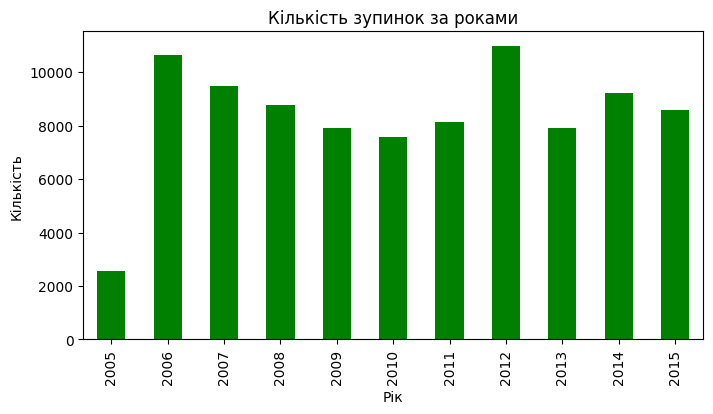

Найменше зупинок було у році: 2005


In [15]:
df['stop_date'] = pd.to_datetime(df['stop_date'])
df['year'] = df['stop_date'].dt.year

stops_per_year = df['year'].value_counts().sort_index()
print(stops_per_year)

stops_per_year.plot(kind='bar', figsize=(8,4), color="green")
plt.title("Кількість зупинок за роками")
plt.ylabel("Кількість")
plt.xlabel("Рік")
plt.show()

print("Найменше зупинок було у році:", stops_per_year.idxmin())